# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [1]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


In [2]:
!nvidia-smi

Sun Aug 23 14:26:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## CONFIG

In [8]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 15,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, # Ustaw None, aby trenować na pełnym zbiorze
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 15, 'max_steps_per_epoch': None}


In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

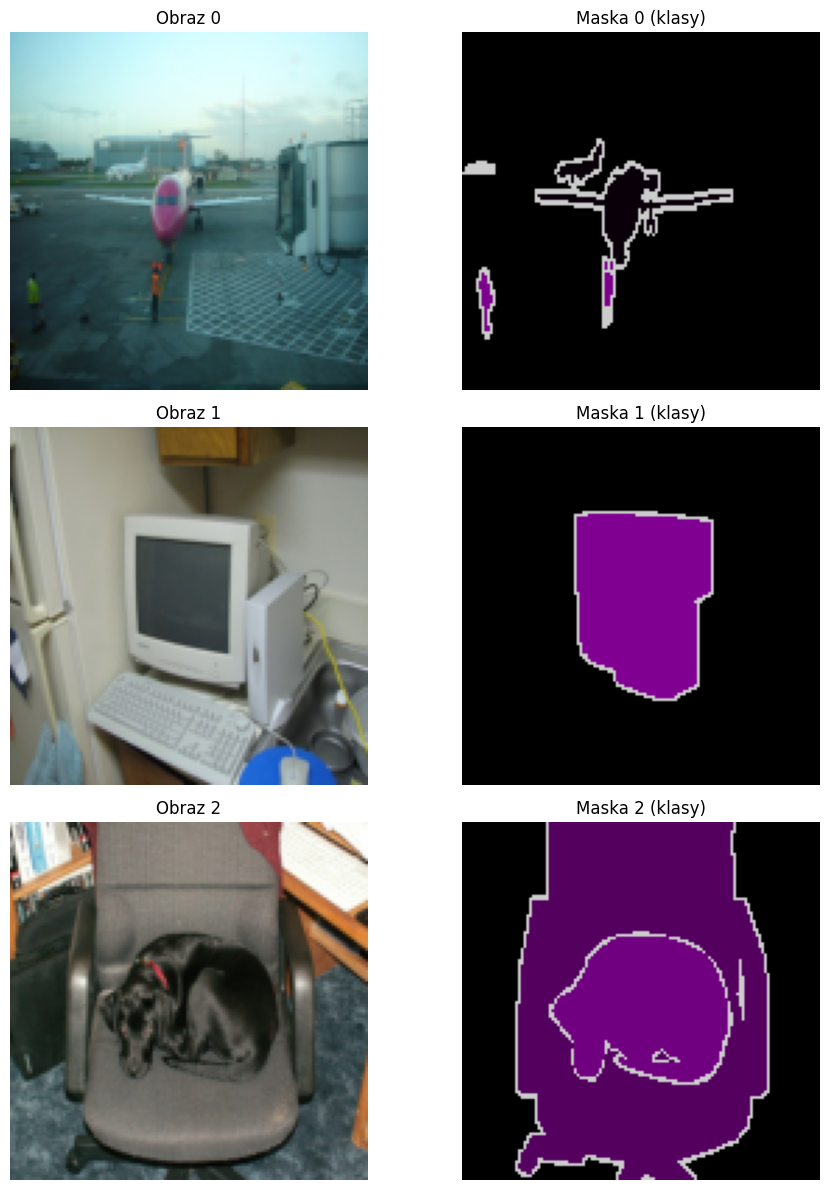

In [10]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

In [ ]:
import torch.nn as nn
import torch

class ConvBlock(nn.Module):
    """
    ZADANIE: Zaimplementuj blok: [Conv 3x3, BN, ReLU] x 2.
    Pamiętaj o padding=1, aby nie zmniejszać wymiarów obrazu.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # TODO: Zdefiniuj self.net jako nn.Sequential z odpowiednimi warstwami
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1),  #ekstrakcja cech 
            nn.BatchNorm2d(out_ch),   #stabilizacja treningu
            nn.ReLU(),   

            # nie podwajamy kanałów w drugim konwolucyjnym bloku?
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    """
    ZADANIE: Zdefiniuj warstwy encodera, bottlenecku i decodera w __init__.
    Dobierz kanały tak, aby pasowały do logiki konkatenacji w forward.
    """
    def __init__(self, in_channels=3, base=16, num_classes=21):
        super().__init__()
        # --- Encoder ---
        # TODO: zdefiniuj self.enc1, self.pool1, self.enc2, self.pool2
        self.enc1 = ConvBlock(in_ch=in_channels, out_ch=base) #ekstrakcja cech z obrazu wejściowego
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) #redukuje wymiary obrazu o połowę
        self.enc2 = ConvBlock(in_ch=base, out_ch=base * 2) #po redukcji wymiarów, podwajamy liczbę kanałów
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) #redukuje wymiary obrazu o połowę

        # --- Bottleneck ---
        # TODO: zdefiniuj self.bottleneck
        self.bottleneck = ConvBlock(in_ch=base * 2, out_ch=base * 4) #po redukcji wymiarów, podwajamy liczbę kanałów

        # --- Decoder ---
        # TODO: zdefiniuj self.up2, self.dec2, self.up1, self.dec1
        # Wskazówka: self.dec2 przyjmuje kanały z (up2 + enc2)
        self.up2 = nn.ConvTranspose2d(in_channels=base * 4, out_channels=base * 2, kernel_size=2, stride=2) #up-sampling, zwiększamy o połowę wymiary obrazu, zmniejszamy liczbę kanałów o połowę
        self.dec2 = ConvBlock(in_ch=base * 4, out_ch=base * 2)
        self.up1 = nn.ConvTranspose2d(in_channels=base * 2, out_channels=base, kernel_size=2, stride=2) #up-sampling
        self.dec1 = ConvBlock(in_ch=base * 2, out_ch=base) 

        # --- Output ---
        # TODO: zdefiniuj self.final (Conv 1x1)
        self.final = nn.Conv2d(in_channels=base, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# Inicjalizacja modelu - studenci mogą tu zmieniać parametr 'base'
model = SmallUNet(base=32).to(device)

In [ ]:
def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    # Maskujemy piksele o wartości 255 (krawędzie/obramowania obiektów w VOC), 
    # aby nie wpływały na ocenę dokładności modelu
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()

In [27]:
# criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
# optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])


# best_val_acc = -1.0

# for epoch in range(CONFIG["epochs"]):
#     model.train()
#     running = 0.0
#     steps = 0

#     for step, (imgs, masks) in enumerate(train_loader):
#         if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
#             break
#         imgs = imgs.to(device, non_blocking=True)
#         masks = masks.to(device, non_blocking=True)
#         logits = model(imgs)
#         loss = criterion(logits, masks)
#         optimizer.zero_grad(set_to_none=True)
#         loss.backward()
#         optimizer.step()

#         running += loss.item()
#         steps += 1

#     model.eval()
#     accs = []
#     with torch.no_grad():
#         for imgs, masks in val_loader:
#             imgs = imgs.to(device, non_blocking=True)
#             masks = masks.to(device, non_blocking=True)
#             logits = model(imgs)
#             accs.append(pixel_accuracy(logits, masks))

#     val_acc = float(np.mean(accs))
#     train_loss = running / max(1, steps)
#     best_val_acc = max(best_val_acc, val_acc)

#     print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

# print("best_val_acc:", best_val_acc)


### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

In [26]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    header_text = "Legenda klas:\n" + \
                    " | ".join(VOC_CLASSES[:11]) + "\n" + \
                    " | ".join(VOC_CLASSES[11:])
                  
    plt.suptitle(header_text, fontsize=11, y=1.02, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
    plt.tight_layout()
    plt.show()

# visualize_predictions(model, val_ds, device)

### Przetestujmy *base=32* i *base=64*

In [18]:
def train_model(base_channels, config, train_loader, val_loader, device):    
    model = SmallUNet(base=base_channels).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=config["ignore_index"])
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    
    history = {"train_loss": [], "val_acc": []}
    best_val_acc = -1.0

    for epoch in range(config["epochs"]):
        # Faza Treningowa
        model.train()
        running_loss = 0.0
        steps = 0

        for step, (imgs, masks) in enumerate(train_loader):
            if config["max_steps_per_epoch"] is not None and step >= config["max_steps_per_epoch"]:
                break
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            logits = model(imgs)
            loss = criterion(logits, masks)
            
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            steps += 1

        # Faza Walidacji
        model.eval()
        accs = []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                logits = model(imgs)
                accs.append(pixel_accuracy(logits, masks))

        val_acc = float(np.mean(accs))
        train_loss = running_loss / max(1, steps)
        best_val_acc = max(best_val_acc, val_acc)
        
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{config['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

    print(f"best_val_acc (base={base_channels}): {best_val_acc:.4f}")
    return model, history

In [19]:
model_base32, history_32 = train_model(base_channels=32, config=CONFIG, train_loader=train_loader, val_loader=val_loader, device=device)
model_base64, history_64 = train_model(base_channels=64, config=CONFIG, train_loader=train_loader, val_loader=val_loader, device=device)

Epoch 01/15 | train_loss=1.8499 | val_pixel_acc=0.7281
Epoch 02/15 | train_loss=1.2499 | val_pixel_acc=0.7293
Epoch 03/15 | train_loss=1.2201 | val_pixel_acc=0.7293
Epoch 04/15 | train_loss=1.2036 | val_pixel_acc=0.7317
Epoch 05/15 | train_loss=1.1964 | val_pixel_acc=0.7278
Epoch 06/15 | train_loss=1.1834 | val_pixel_acc=0.7319
Epoch 07/15 | train_loss=1.1669 | val_pixel_acc=0.7309
Epoch 08/15 | train_loss=1.1428 | val_pixel_acc=0.7317
Epoch 09/15 | train_loss=1.1302 | val_pixel_acc=0.7339
Epoch 10/15 | train_loss=1.1124 | val_pixel_acc=0.7350
Epoch 11/15 | train_loss=1.0996 | val_pixel_acc=0.7290
Epoch 12/15 | train_loss=1.0879 | val_pixel_acc=0.7242
Epoch 13/15 | train_loss=1.0784 | val_pixel_acc=0.7340
Epoch 14/15 | train_loss=1.0605 | val_pixel_acc=0.7314
Epoch 15/15 | train_loss=1.0582 | val_pixel_acc=0.7349
best_val_acc (base=32): 0.7350
Epoch 01/15 | train_loss=1.5644 | val_pixel_acc=0.7291
Epoch 02/15 | train_loss=1.2340 | val_pixel_acc=0.7305
Epoch 03/15 | train_loss=1.2122 | 

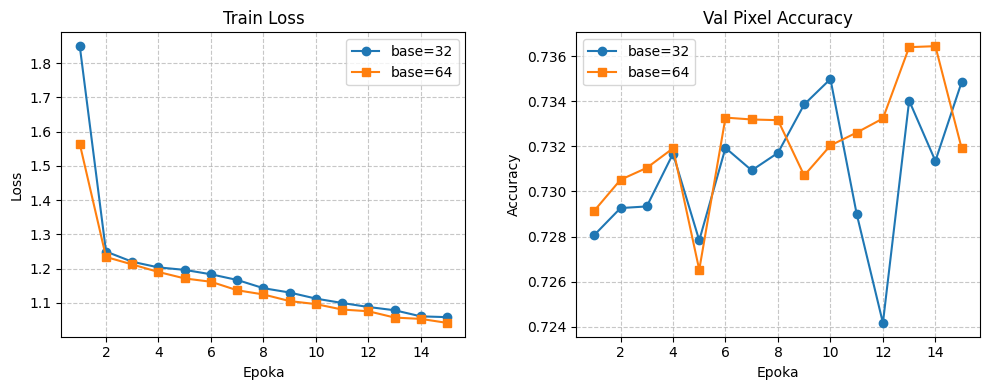

In [30]:
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(10, 4))

# Train Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_32["train_loss"], label='base=32', marker='o')
plt.plot(epochs_range, history_64["train_loss"], label='base=64', marker='s')
plt.title("Train Loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Val Pixel Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_32["val_acc"], label='base=32', marker='o')
plt.plot(epochs_range, history_64["val_acc"], label='base=64', marker='s')
plt.title("Val Pixel Accuracy")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout(w_pad=3.0)
plt.show()

Train Loss:

- Widzimy, że większa liczba epok zmniejsza wartości funkcji straty
- Zmiana base z 32 na 64 nieznacznie przyspieszyła spadek straty i pozwoliła osiągnąć minimalnie niższy wynik końcowy.

Val Pixel Accuracy:

- Wynik Val Pixel Accuracy na poziomie ~73% jest w miarę wysoki wynik, ale przy wizualizacji poniżej widać, że złudny, pewnie dlatego, że tło stanowi większą część obrazków
- Zwiększenie base nie poprawiło znacząco ogólnej dokładności

Wizualizacja dla base=32


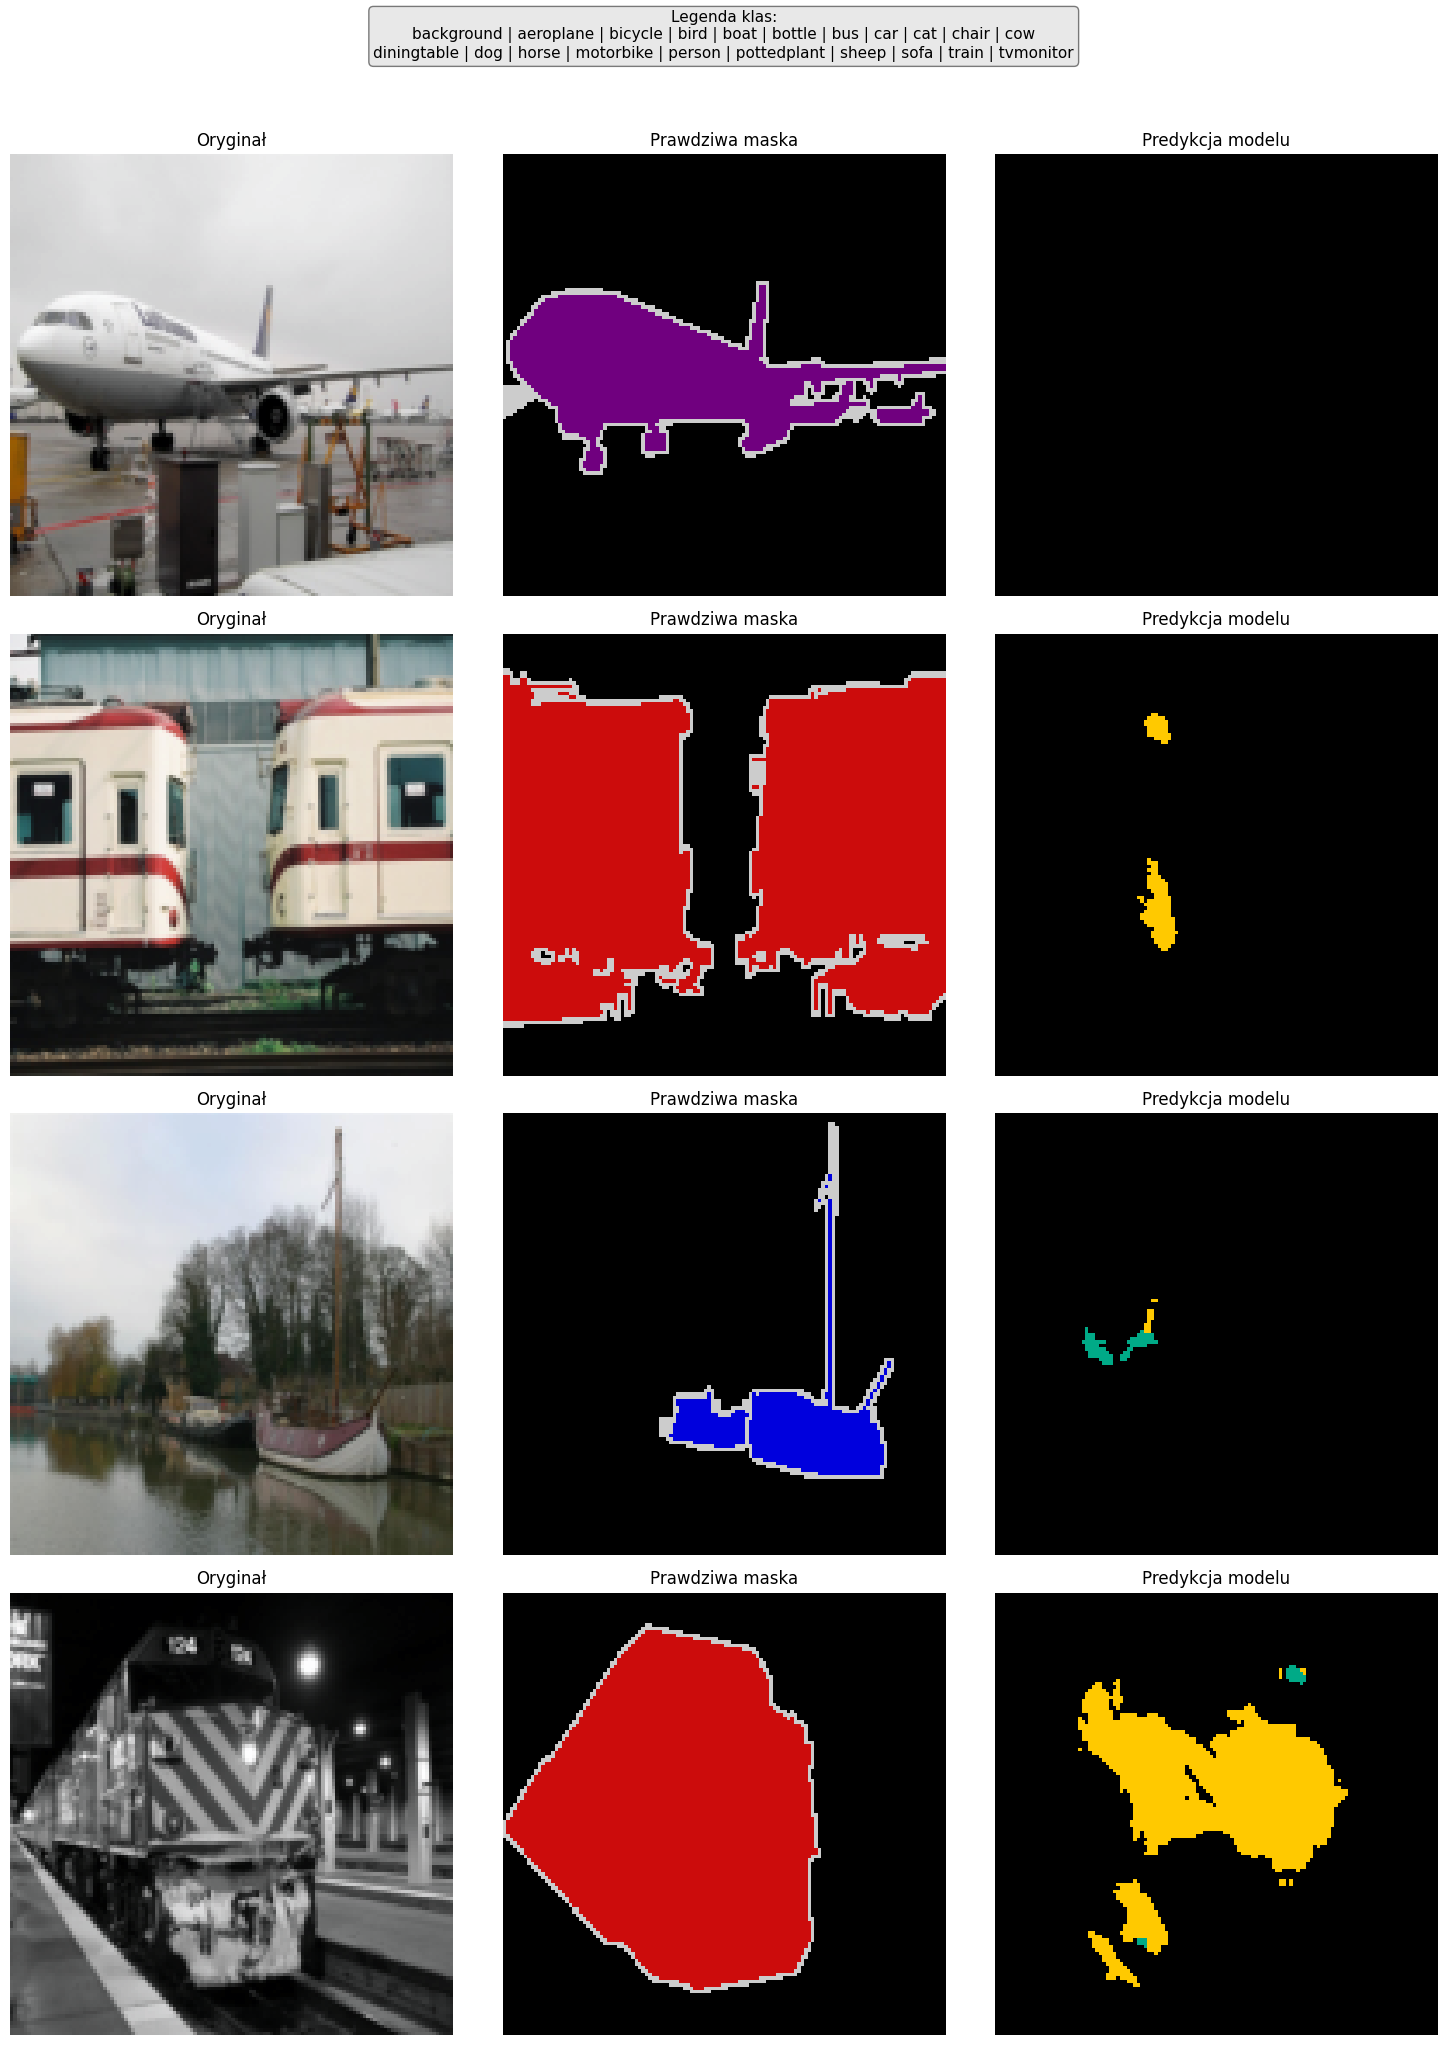

Wizualizacja dla base=64


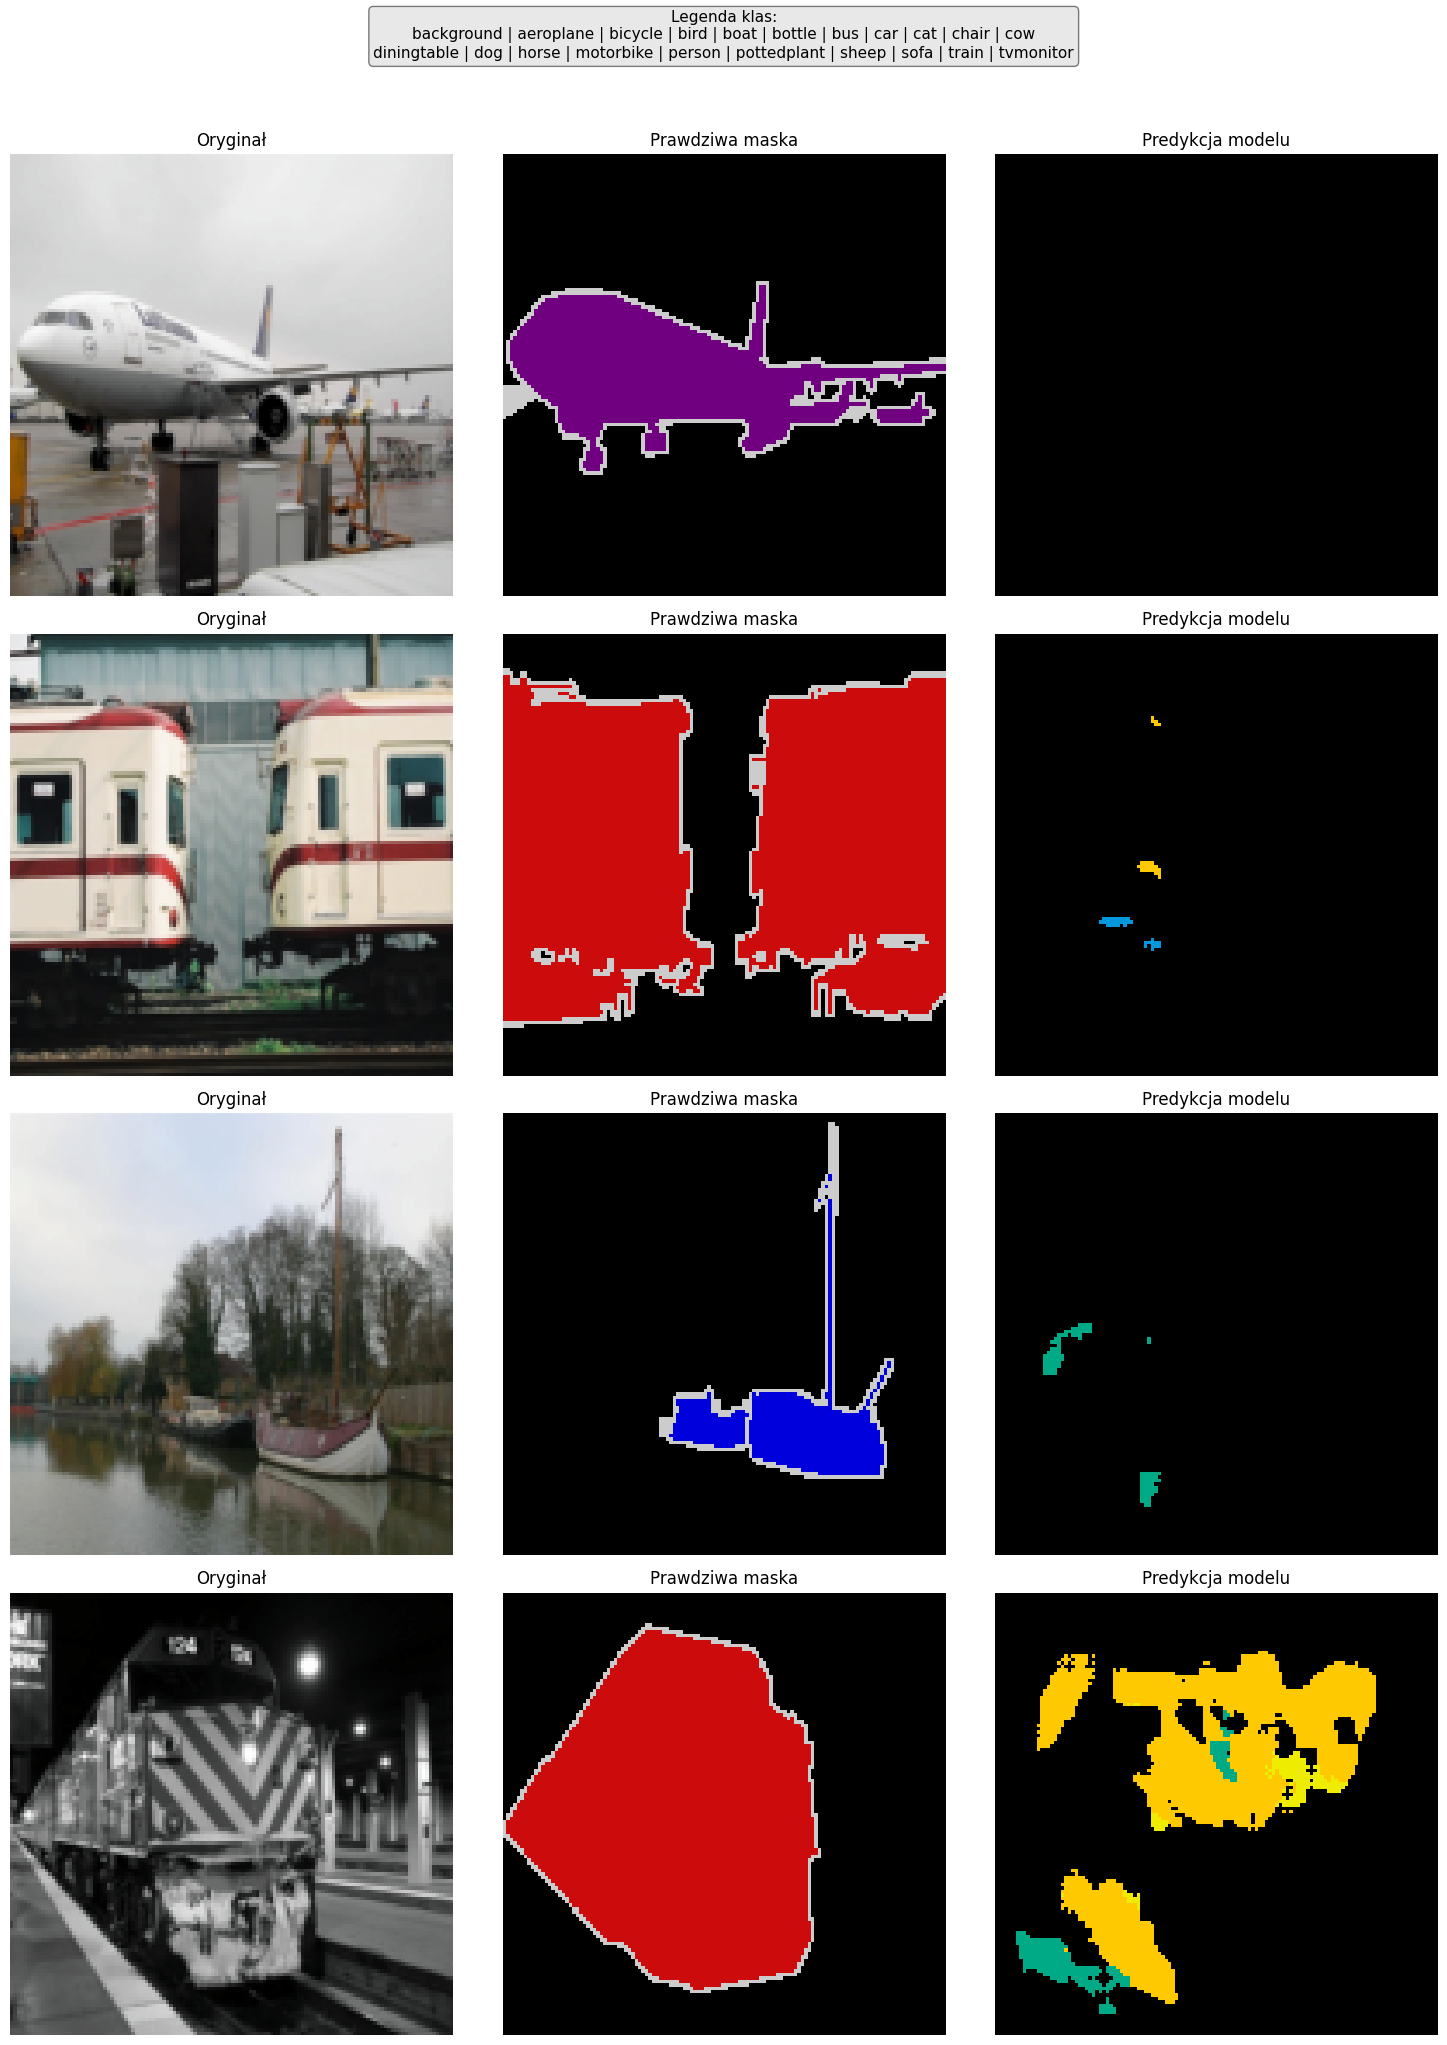

In [21]:
print("Wizualizacja dla base=32")
visualize_predictions(model_base32, val_ds, device)

print("Wizualizacja dla base=64")
visualize_predictions(model_base64, val_ds, device)

- Oba modele dają dość słabą jakość segmentacji - niekiedy całkowicie pomijają obiekty (np. samolot na pierwszym obrazie)
- W przypadku ostatniego obrazu (pociąg):

    - Model base=32 wyznaczył spójniejszy obszar (choć pomylił klasę).

    - Model base=64 stworzył maskę poszarpaną, składającą się z kilku klas (wewnątrz jednego obiektu).

    - Można, więc chyba powiedzieć, że sam wzrost *base* bez pogłębienia sieci nie wystarczy do poprawy jakości segmentacji